In [1]:
import time
import matplotlib.pyplot as plt 
import os
os.chdir('../')
import torch
import psutil
import numpy as np
import torch.nn as nn
from typing import List, Tuple, Optional
import matplotlib.pyplot as plt
import random 
from decimal import Decimal
import deepwave
import warnings
import torch.nn.functional as F
from functools import partial
from torchaudio.functional import biquad
from scipy.signal import butter
warnings.filterwarnings('ignore')
import os
from ultils.utils import *
os.environ['KMP_DUPLICATE_LIB_OK']='True'


libgomp: Invalid value for environment variable OMP_NUM_THREADS

libgomp: Invalid value for environment variable OMP_NUM_THREADS


In [2]:
gpu_count = torch.cuda.device_count()
print(f"The number of available GPUs is: {gpu_count}")
if torch.cuda.is_available():
    DEVICE = torch.device("cuda:0")  
    print(f"The selected GPU device is: {torch.cuda.get_device_name(DEVICE)}")
else:
    DEVICE = torch.device("cpu")
    print("No available GPUs detected, switched to using CPU")

The number of available GPUs is: 1
The selected GPU device is: NVIDIA GeForce RTX 4090


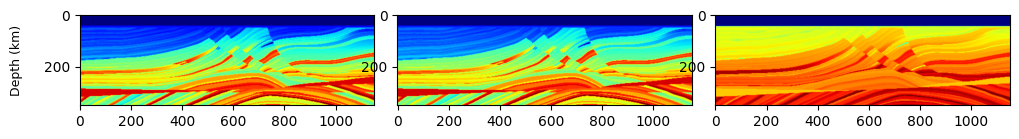

max values: tensor(4766.6040) tensor(2752.) tensor(2626.9998)
min values: tensor(1500.) tensor(800.) tensor(1009.)
model shape: torch.Size([352, 1150]) torch.Size([352, 1150]) torch.Size([352, 1150])


In [3]:
######### load data #########
dx = 10

vp_true = torch.tensor(np.load('./marmousi_model/vp_truex352x1150x10.npy'))
vs_true = torch.tensor(np.load('./marmousi_model/vs_truex352x1150x10.npy'))
rho_true = torch.tensor(np.load('./marmousi_model/rho_truex352x1150x10.npy'))


submarine_deep = 43
submarine_vp = 1500                                      #water layer vp
submarine_vs = 800  ##to obay the CFL condition                                         #water layer vs
submarine_rho = 1009
  
vp_true[:submarine_deep,:] = submarine_vp
vs_true[:submarine_deep,:] = submarine_vs
rho_true[:submarine_deep,:] = submarine_rho


fig, ax = plt.subplots(1, 3, figsize=(12, 16))
fig1 = ax[0].imshow(vp_true.cpu().numpy(), cmap= 'jet',vmin = vp_true.min(),vmax = vp_true.max())
ax[0].set_ylabel("Depth (km)\n",fontsize=9)
fig2 = ax[1].imshow(vs_true.cpu().numpy(), cmap= 'jet',vmin = vs_true.min(),vmax = vs_true.max())
fig3 = ax[2].imshow(rho_true.cpu().numpy(), cmap= 'jet',vmin = rho_true.min(),vmax = rho_true.max())
plt.subplots_adjust(hspace=-0.84,wspace=0.08) 
plt.show()
print("max values:",vp_true.max(),vs_true.max(),rho_true.max())
print("min values:",vp_true.min(),vs_true.min(),rho_true.min())
print("model shape:",vp_true.shape,vs_true.shape,rho_true.shape)

17.387997
tensor(3927.0754, device='cuda:0') tensor(1847.8777, device='cuda:0')
tensor(1009., device='cuda:0') tensor(2409.4448, device='cuda:0')


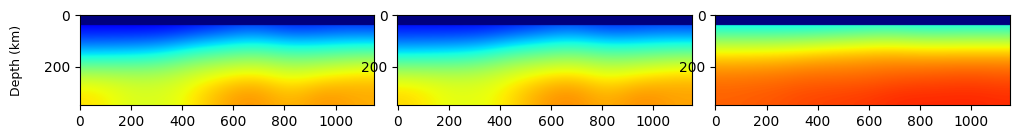

In [4]:
import scipy.ndimage
import scipy.io

sigma = 30

times = 6
if times != 0:
    vp_initial,vs_initial,rho_initial = gaussian_smooth_n_times(vp_true, vs_true, rho_true, sigma, times, DEVICE)
else:
    vp_initial,vs_initial,rho_initial = gaussian_smooth_once(vp_true, vs_true, rho_true, sigma, DEVICE)

snr_vp = ComputeSNR(vp_initial.detach().cpu().numpy(), \
                  vp_true.detach().cpu().numpy())

print(snr_vp)
print(vp_initial.max(),vp_initial.min())
vp_initial[:submarine_deep,:] = submarine_vp
vs_initial[:submarine_deep,:] = submarine_vs
rho_initial[:submarine_deep,:] = submarine_rho

print(rho_initial.min(),rho_initial.max())

fig, ax = plt.subplots(1, 3, figsize=(12, 16))
fig1 = ax[0].imshow(vp_initial.cpu().numpy(), cmap= 'jet',vmin = vp_true.min(),vmax = vp_true.max())
ax[0].set_ylabel("Depth (km)\n",fontsize=9)
fig2 = ax[1].imshow(vs_initial.cpu().numpy(), cmap= 'jet',vmin = vs_true.min(),vmax = vs_true.max())
fig3 = ax[2].imshow(rho_initial.cpu().numpy(), cmap= 'jet',vmin = rho_true.min(),vmax = rho_true.max())
plt.subplots_adjust(hspace=-0.84,wspace=0.08) 
plt.show()

In [5]:
loss_fn = 'l1'  

if times != 0:
    ##### save path
    vp_save_path = f'./rec/reconstruction_ms/EFWI_en/init_2/vp/'
    vs_save_path = f'./rec/reconstruction_ms/EFWI_en/init_2/vs/'
    rho_save_path = f'./rec/reconstruction_ms/EFWI_en/init_2/rho/'
    main_path = f'./log_data/log_data_ms/EFWI_en/init_2/'
else:
    vp_save_path = f'./rec/reconstruction_ms/EFWI_en/init_1/vp/'
    vs_save_path = f'./rec/reconstruction_ms/EFWI_en/init_1/vs/'
    rho_save_path = f'./rec/reconstruction_ms/EFWI_en/init_1/rho/'
    main_path = f'./log_data/log_data_ms/EFWI_en/init_1/'


if not os.path.exists(main_path):
    os.makedirs(main_path)

if not os.path.exists(vp_save_path):
    os.makedirs(vp_save_path)
if not os.path.exists(vs_save_path):
    os.makedirs(vs_save_path)
if not os.path.exists(rho_save_path):
    os.makedirs(rho_save_path)
    


In [6]:
Physics = Physics_deepwave                              
                           
model_shape = [vp_true.shape[0], vp_true.shape[1]]                                 
                                                                                       
DT = 0.006                                               
F_PEAK = 8                                              
DH = dx                                                  

inpa = {                                
    'fdom': F_PEAK, 
    'dh': DH,   
    'dt': DT
}

NT = 2500

In [7]:
### load obs and src, src_loc, rec_loc
obs_file_vx = './obs_data/d_obs_vx_src.npy'
obs_file_vy = './obs_data/d_obs_vy_src.npy'
d_obs_vx = torch.tensor(np.load(obs_file_vx))
d_obs_vy = torch.tensor(np.load(obs_file_vy))

src_loc = torch.tensor(np.load('./src_rec_positions/src_loc.npy'))
rec_loc = torch.tensor(np.load('./src_rec_positions/rec_loc.npy'))
src     = torch.tensor(np.load('./sources/src.npy'))

### sum source
num_super_sources = 10
sources_per_super = 10
source_distribution = 'random'# ('random' 或 'uniform')

#### 1.
result = encode_sources(obs_data_vx = d_obs_vx.squeeze(0),
                        obs_data_vy = d_obs_vy.squeeze(0),
                        source_locations = src_loc, 
                        receiver_locations  = rec_loc, 
                        source_functions = src,
                        num_super_sources = num_super_sources,
                        sources_per_super = sources_per_super,
                        source_distribution=source_distribution
                        )

#### 2
print(f"Encoded observation data shape (vx): {result['encoded_obs_data_vx'].shape}")
print(f"Encoded observation data shape (vy): {result['encoded_obs_data_vy'].shape}")
print(f"Encoded source location shape: {result['encoded_source_locations'].shape}")
print(f"Encoded receiver location shape: {result['encoded_receiver_locations'].shape}")
print(f"Encoded source function shape: {result['encoded_source_functions'].shape}")


d_obs_vx_encode = result['encoded_obs_data_vx'].unsqueeze(0).to(DEVICE)
d_obs_vy_encode = result['encoded_obs_data_vy'].unsqueeze(0).to(DEVICE)
src_loc_encode  = result['encoded_source_locations'].to(DEVICE)
rec_loc_encode  = result['encoded_receiver_locations'].to(DEVICE)
src_encode      = result['encoded_source_functions'].to(DEVICE)



Encoded observation data shape (vx): torch.Size([10, 2500, 1130])
Encoded observation data shape (vy): torch.Size([10, 2500, 1130])
Encoded source location shape: torch.Size([10, 10, 2])
Encoded receiver location shape: torch.Size([10, 1130, 2])
Encoded source function shape: torch.Size([10, 10, 2500])


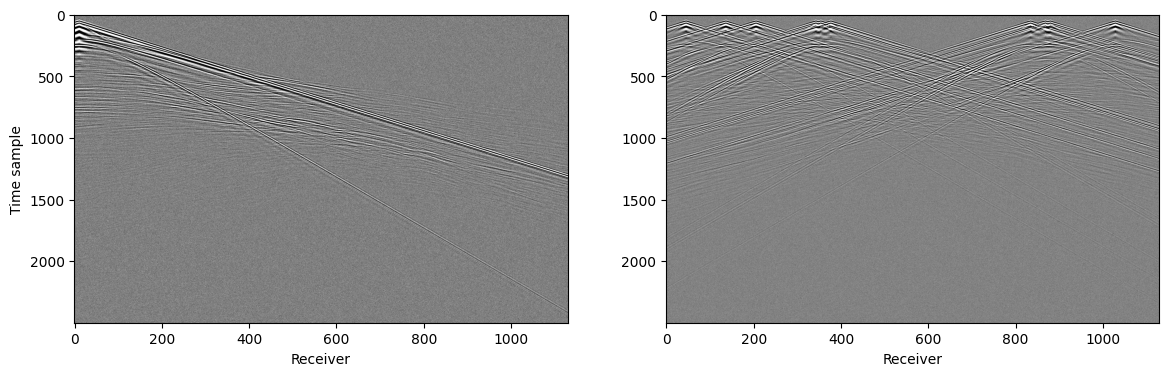

In [8]:

##### show these data
d_obs_vx_plot = d_obs_vx.squeeze(0)
d_obs_vx_en_plot = d_obs_vx_encode.squeeze(0)
vmin, vmax = torch.quantile(d_obs_vx_plot[1],
                            torch.tensor([0.01, 0.99]))
vsmin, vsmax = torch.quantile(d_obs_vx_en_plot[1],
                                 torch.tensor([0.01, 0.99]).to(DEVICE))


fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].imshow(d_obs_vx_plot[1].cpu().detach().numpy(), aspect='auto', cmap='gray',vmin=vmin, vmax=vmax)
ax[0].set_xlabel("Receiver")
ax[0].set_ylabel("Time sample")
ax[1].imshow(d_obs_vx_en_plot[1].cpu().detach().numpy(), aspect='auto', cmap='gray',vmin=vsmin, vmax=vsmax)
ax[1].set_xlabel("Receiver")
plt.subplots_adjust(hspace=0.6)  
plt.show()


In [9]:
vp_initial = vp_initial.to(DEVICE)
vs_initial = vs_initial.to(DEVICE)
rho_initial = rho_initial.to(DEVICE)
vp = vp_initial.requires_grad_(True)
vs = vs_initial.requires_grad_(True)
rho = rho_initial.requires_grad_(True)

criteria = torch.nn.L1Loss(reduction='sum')
criteria_model = torch.nn.L1Loss(reduction='sum')

optimer = torch.optim.Adam([{'params': [vp], 'lr': 6.0},
                            {'params': [vs], 'lr': 4.0},
                            {'params': [rho], 'lr': 2.0}])

In [10]:
all_loss_data = []
all_loss_vx_model = []
all_loss_vy_model = []
all_loss_rho_model = []
all_loss_model =[]
SNR_vp = []
SSIM_vp = []
Loss_vp = []
ERROR_vp = []
SNR_vs = []
SSIM_vs = []
Loss_vs = []
ERROR_vs = []
SNR_rho = []
SSIM_rho = []
Loss_rho = []
ERROR_rho = []
time_each_iter = []
def get_cpu_memory():
    process = psutil.Process(os.getpid())
    mem_info = process.memory_info()
    return mem_info.rss / 1024 ** 2   
    
def get_gpu_memory():
    if torch.cuda.is_available():
        
        return torch.cuda.memory_allocated() / 1024 ** 2
    else:
        return 0
cpu_mem_log = [] 
gpu_mem_log = []

Now inversion on freq: 4
Iteration 5 = loss: 5.1668,model loss: 266162752.0000,time:6.96,snr_vp:18.236,snr_vs:18.321,snr_rho:22.617
Iteration 10 = loss: 4.9737,model loss: 262527472.0000,time:7.06,snr_vp:18.303,snr_vs:18.438,snr_rho:22.712
Iteration 15 = loss: 4.8416,model loss: 259039264.0000,time:7.01,snr_vp:18.372,snr_vs:18.520,snr_rho:22.814
Iteration 20 = loss: 4.7776,model loss: 256147228.0000,time:6.98,snr_vp:18.437,snr_vs:18.591,snr_rho:22.900


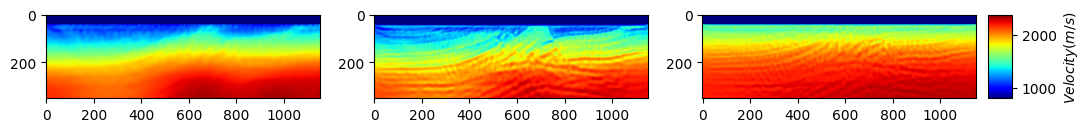

Iteration 25 = loss: 4.7494,model loss: 253744120.0000,time:7.01,snr_vp:18.495,snr_vs:18.661,snr_rho:22.964
Iteration 30 = loss: 4.7333,model loss: 251678268.0000,time:7.01,snr_vp:18.546,snr_vs:18.727,snr_rho:23.012
Iteration 35 = loss: 4.7215,model loss: 249878700.0000,time:6.99,snr_vp:18.592,snr_vs:18.787,snr_rho:23.055
Iteration 40 = loss: 4.7120,model loss: 248303596.0000,time:7.00,snr_vp:18.635,snr_vs:18.841,snr_rho:23.093


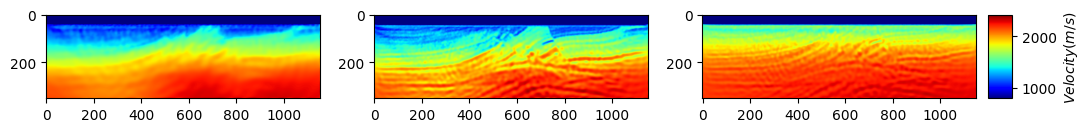

Iteration 45 = loss: 4.7042,model loss: 246937672.0000,time:7.02,snr_vp:18.673,snr_vs:18.890,snr_rho:23.126
Iteration 50 = loss: 4.6976,model loss: 245743348.0000,time:7.00,snr_vp:18.709,snr_vs:18.935,snr_rho:23.156
Now inversion on freq: 6
Iteration 5 = loss: 6.1332,model loss: 240007152.0000,time:7.01,snr_vp:18.876,snr_vs:19.178,snr_rho:23.237
Iteration 10 = loss: 6.0131,model loss: 234806828.0000,time:8.02,snr_vp:19.044,snr_vs:19.332,snr_rho:23.268
Iteration 15 = loss: 5.9590,model loss: 230795708.0000,time:8.04,snr_vp:19.183,snr_vs:19.452,snr_rho:23.272
Iteration 20 = loss: 5.9268,model loss: 227616840.0000,time:8.04,snr_vp:19.301,snr_vs:19.546,snr_rho:23.271


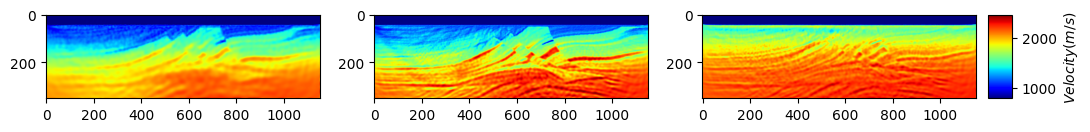

Iteration 25 = loss: 5.9070,model loss: 224995164.0000,time:8.08,snr_vp:19.403,snr_vs:19.619,snr_rho:23.268
Iteration 30 = loss: 5.8917,model loss: 222768832.0000,time:8.04,snr_vp:19.493,snr_vs:19.679,snr_rho:23.264
Iteration 35 = loss: 5.8809,model loss: 220829320.0000,time:8.03,snr_vp:19.573,snr_vs:19.728,snr_rho:23.261
Iteration 40 = loss: 5.8726,model loss: 219130000.0000,time:8.03,snr_vp:19.644,snr_vs:19.769,snr_rho:23.257


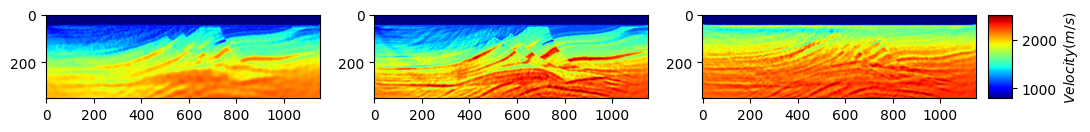

Iteration 45 = loss: 5.8639,model loss: 217626584.0000,time:8.03,snr_vp:19.709,snr_vs:19.803,snr_rho:23.254
Iteration 50 = loss: 5.8573,model loss: 216274612.0000,time:8.05,snr_vp:19.768,snr_vs:19.832,snr_rho:23.251
Now inversion on freq: 8
Iteration 5 = loss: 7.0388,model loss: 211972240.0000,time:8.02,snr_vp:19.922,snr_vs:20.000,snr_rho:23.273
Iteration 10 = loss: 7.0262,model loss: 208156700.0000,time:8.03,snr_vp:20.061,snr_vs:20.065,snr_rho:23.277
Iteration 15 = loss: 7.0464,model loss: 205326616.0000,time:8.02,snr_vp:20.169,snr_vs:20.117,snr_rho:23.280
Iteration 20 = loss: 6.9572,model loss: 203092840.0000,time:8.01,snr_vp:20.256,snr_vs:20.154,snr_rho:23.280


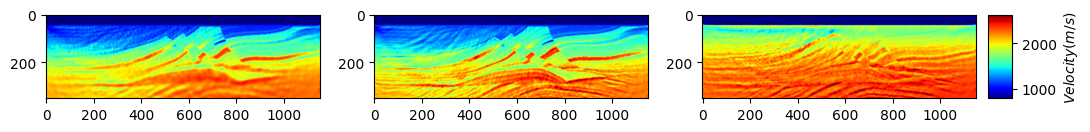

Iteration 25 = loss: 6.9246,model loss: 201253564.0000,time:8.05,snr_vp:20.330,snr_vs:20.192,snr_rho:23.279
Iteration 30 = loss: 6.9057,model loss: 199662268.0000,time:8.02,snr_vp:20.395,snr_vs:20.226,snr_rho:23.279
Iteration 35 = loss: 6.9002,model loss: 198325588.0000,time:8.02,snr_vp:20.451,snr_vs:20.258,snr_rho:23.279
Iteration 40 = loss: 6.8906,model loss: 197144284.0000,time:8.02,snr_vp:20.501,snr_vs:20.290,snr_rho:23.279


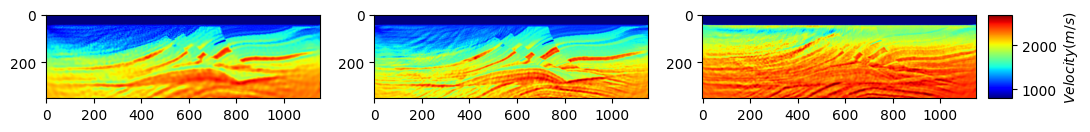

Iteration 45 = loss: 6.8841,model loss: 196119012.0000,time:8.03,snr_vp:20.546,snr_vs:20.319,snr_rho:23.280
Iteration 50 = loss: 6.8755,model loss: 195203920.0000,time:8.04,snr_vp:20.587,snr_vs:20.349,snr_rho:23.280
Now inversion on freq: 10
Iteration 5 = loss: 7.8697,model loss: 192698744.0000,time:8.22,snr_vp:20.672,snr_vs:20.460,snr_rho:23.298
Iteration 10 = loss: 7.8673,model loss: 190422040.0000,time:8.03,snr_vp:20.751,snr_vs:20.530,snr_rho:23.305
Iteration 15 = loss: 7.9977,model loss: 188613328.0000,time:8.02,snr_vp:20.814,snr_vs:20.580,snr_rho:23.311
Iteration 20 = loss: 7.8680,model loss: 187222672.0000,time:8.06,snr_vp:20.867,snr_vs:20.617,snr_rho:23.314


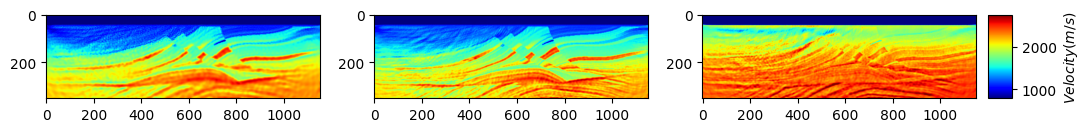

Iteration 25 = loss: 7.7978,model loss: 185991952.0000,time:8.02,snr_vp:20.915,snr_vs:20.649,snr_rho:23.314
Iteration 30 = loss: 7.7795,model loss: 184974696.0000,time:8.05,snr_vp:20.958,snr_vs:20.680,snr_rho:23.315
Iteration 35 = loss: 7.7654,model loss: 184039192.0000,time:8.02,snr_vp:20.997,snr_vs:20.712,snr_rho:23.317
Iteration 40 = loss: 7.7545,model loss: 183225296.0000,time:8.02,snr_vp:21.031,snr_vs:20.743,snr_rho:23.319


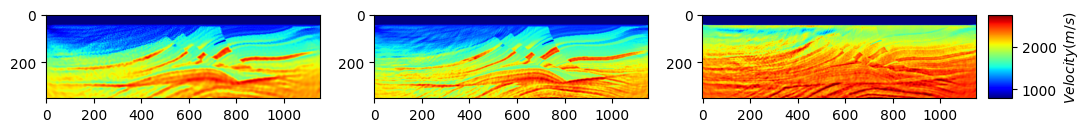

Iteration 45 = loss: 7.7420,model loss: 182484692.0000,time:8.03,snr_vp:21.064,snr_vs:20.776,snr_rho:23.321
Iteration 50 = loss: 7.7263,model loss: 181811400.0000,time:8.04,snr_vp:21.094,snr_vs:20.809,snr_rho:23.325
Now inversion on freq: 12
Iteration 5 = loss: 8.5540,model loss: 180361224.0000,time:8.04,snr_vp:21.146,snr_vs:20.879,snr_rho:23.338
Iteration 10 = loss: 8.6377,model loss: 179063340.0000,time:8.03,snr_vp:21.195,snr_vs:20.933,snr_rho:23.350
Iteration 15 = loss: 8.5963,model loss: 177914668.0000,time:8.04,snr_vp:21.235,snr_vs:20.981,snr_rho:23.363
Iteration 20 = loss: 8.6049,model loss: 176995784.0000,time:8.03,snr_vp:21.270,snr_vs:21.023,snr_rho:23.378


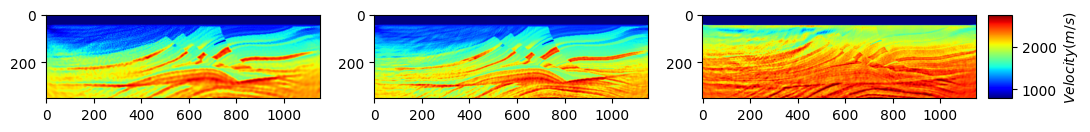

Iteration 25 = loss: 8.5271,model loss: 176205136.0000,time:8.03,snr_vp:21.303,snr_vs:21.059,snr_rho:23.392
Iteration 30 = loss: 8.4595,model loss: 175431672.0000,time:8.03,snr_vp:21.333,snr_vs:21.095,snr_rho:23.408
Iteration 35 = loss: 8.4271,model loss: 174780824.0000,time:8.04,snr_vp:21.361,snr_vs:21.134,snr_rho:23.429
Iteration 40 = loss: 8.4367,model loss: 174073908.0000,time:8.02,snr_vp:21.388,snr_vs:21.172,snr_rho:23.455


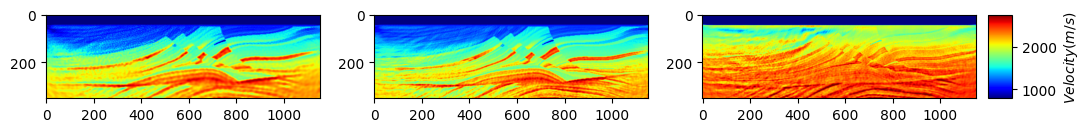

Iteration 45 = loss: 8.3988,model loss: 173351504.0000,time:8.13,snr_vp:21.414,snr_vs:21.217,snr_rho:23.489
Iteration 50 = loss: 8.3579,model loss: 172546496.0000,time:8.04,snr_vp:21.443,snr_vs:21.265,snr_rho:23.533
Now inversion on freq: 15
Iteration 5 = loss: 9.3717,model loss: 171238992.0000,time:8.04,snr_vp:21.485,snr_vs:21.326,snr_rho:23.581
Iteration 10 = loss: 9.3636,model loss: 170100852.0000,time:8.04,snr_vp:21.525,snr_vs:21.377,snr_rho:23.622
Iteration 15 = loss: 9.3318,model loss: 169088900.0000,time:8.02,snr_vp:21.560,snr_vs:21.420,snr_rho:23.655
Iteration 20 = loss: 9.4056,model loss: 168284112.0000,time:8.04,snr_vp:21.591,snr_vs:21.462,snr_rho:23.685


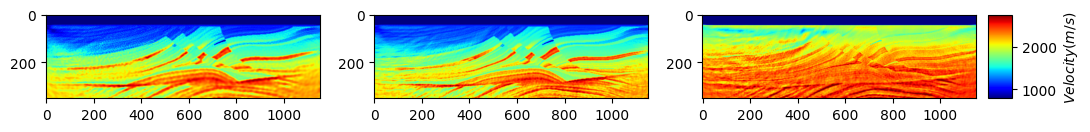

Iteration 25 = loss: 9.3546,model loss: 167549576.0000,time:8.04,snr_vp:21.620,snr_vs:21.496,snr_rho:23.713
Iteration 30 = loss: 9.3338,model loss: 166938156.0000,time:8.04,snr_vp:21.646,snr_vs:21.529,snr_rho:23.739
Iteration 35 = loss: 9.2692,model loss: 166353640.0000,time:8.03,snr_vp:21.672,snr_vs:21.561,snr_rho:23.764
Iteration 40 = loss: 9.2431,model loss: 165846008.0000,time:8.03,snr_vp:21.695,snr_vs:21.589,snr_rho:23.787


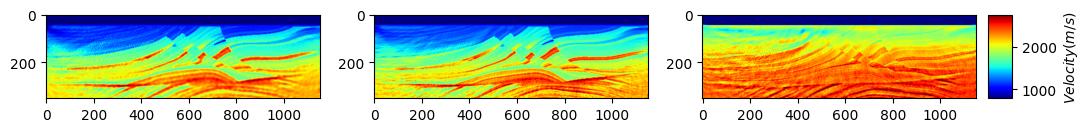

Iteration 45 = loss: 9.2699,model loss: 165362296.0000,time:8.04,snr_vp:21.717,snr_vs:21.618,snr_rho:23.810
Iteration 50 = loss: 9.2745,model loss: 164917280.0000,time:8.04,snr_vp:21.738,snr_vs:21.643,snr_rho:23.831
Running complete in 40m  3s


In [11]:
# Run optimisation/inversion

mini_batches = 5
ITERATION = 50 

freqs = [4,6,8,10,12,15]

import time
t_start = time.time()
for freq in freqs: 
    print('Now inversion on freq:',freq)
    sos = butter(6, freq, fs=1/DT, output='sos') ## default is low pass
    sos = [torch.tensor(sosi).to(d_obs_vx.dtype).to(DEVICE)
           for sosi in sos]

    def filt(x):
        return biquad(biquad(biquad(x, *sos[0]), *sos[1]), *sos[2])

    for iter in range(ITERATION):
        loss_data_minibatch = []
        
        time_each_bath_start = time.time()
        for batch in range(mini_batches):
       
            optimer.zero_grad()
        
            src_loc_batch = src_loc_encode[batch::mini_batches].to(DEVICE)
            rec_loc_batch = rec_loc_encode[batch::mini_batches].to(DEVICE)
            src_batch     = src_encode[batch::mini_batches].to(DEVICE) ## for true source
                
            physics = Physics(inpa['dh'], inpa['dt'],inpa['fdom'] ,size=NT,src=src_batch,
                        src_loc=src_loc_batch, rec_loc=rec_loc_batch
                        )

            with torch.no_grad():
    
                vp[:submarine_deep,:] = submarine_vp
                vs[:submarine_deep,:] = submarine_vs
                rho[:submarine_deep,:] = submarine_rho
            
                vp[vp>vp_true.max()] = vp_true.max()
                vp[vp<vp_true.min()] = vp_true.min()
        
                vs[vs>vs_true.max()] = vs_true.max()
                vs[vs<vs_true.min()] = vs_true.min()
        
                rho[rho>rho_true.max()] = rho_true.max()
                rho[rho<rho_true.min()] = rho_true.min()
               
                vp = vp.requires_grad_(True)
                vs = vs.requires_grad_(True)
                rho = rho.requires_grad_(True)          
        
            vp = vp.to(DEVICE)
            vs = vs.to(DEVICE)
            rho = rho.to(DEVICE)
            
            taux_est = physics(vp,vs,rho) 
            taux_vx_est_filtered = taux_est[0].to(DEVICE)
            taux_vy_est_filtered = taux_est[1].to(DEVICE)
            
            taux_vx_est_filtered =  filt(taux_vx_est_filtered.squeeze(0).permute(0, 2, 1)).permute(0, 2, 1).to(DEVICE).unsqueeze(0)
            taux_vy_est_filtered = filt(taux_vy_est_filtered.squeeze(0).permute(0, 2, 1)).permute(0, 2, 1).to(DEVICE).unsqueeze(0)
            
            taux_est_all = torch.cat((taux_vx_est_filtered,taux_vy_est_filtered),dim=1).to(DEVICE)
         
            d_obs_vx_filtered = d_obs_vx_encode[:, batch::mini_batches].to(DEVICE)
            d_obs_vy_filtered = d_obs_vy_encode[:, batch::mini_batches].to(DEVICE)
            
            d_obs_vx_filtered =  filt(d_obs_vx_filtered.squeeze(0).permute(0, 2, 1)).permute(0, 2, 1).to(DEVICE).unsqueeze(0)
            d_obs_vy_filtered = filt(d_obs_vy_filtered.squeeze(0).permute(0, 2, 1)).permute(0, 2, 1).to(DEVICE).unsqueeze(0)
            
            d_obs_filtered_all = torch.cat((d_obs_vx_filtered,d_obs_vy_filtered),dim=1).to(DEVICE)

            
            if loss_fn == 'l1':
                criteria = torch.nn.L1Loss(reduction='mean')
                loss_data = 3.0e9*criteria(taux_est_all, d_obs_filtered_all)
            if loss_fn == 'l2':
                criteria = torch.nn.MSELoss(reduction='mean')
                loss_data = 1.0e12*criteria(taux_est_all, d_obs_filtered_all)
                
            loss = loss_data
            loss.backward()
            optimer.step()

        all_loss_data.append(loss_data.detach().cpu().item())
        time_each_bath_end = time.time()
        time_each_iter.append(time_each_bath_end - time_each_bath_start)
        
        mem_now_cpu = get_cpu_memory()
        cpu_mem_log.append(mem_now_cpu)
        mem_now_gpu = get_gpu_memory()
        gpu_mem_log.append(mem_now_gpu)
        
        with torch.no_grad():
            all_loss_vx_model.append(
                criteria_model(vp.cpu(),vp_true.cpu()).detach().numpy().item()
            )
            all_loss_vy_model.append(
                criteria_model(vs.cpu(),vs_true.cpu()).detach().numpy().item()
                )
            all_loss_rho_model.append(
                criteria_model(rho.cpu(),rho_true.cpu()).detach().numpy().item()
            )
            all_loss_model.append(
                criteria_model(vp.cpu(),vp_true.cpu()).detach().numpy().item()+ \
                criteria_model(vp.cpu(),vp_true.cpu()).detach().numpy().item()+ \
                criteria_model(rho.cpu(),rho_true.cpu()).detach().numpy().item()
            )
    
        snr_vp = ComputeSNR(vp.detach().cpu().numpy(), \
                  vp_true.detach().cpu().numpy())
        SNR_vp = np.append(SNR_vp, snr_vp)
        snr_vs = ComputeSNR(vs.detach().cpu().numpy(), \
                  vs_true.detach().cpu().numpy())
        SNR_vs = np.append(SNR_vs, snr_vs)
        snr_rho = ComputeSNR(rho.detach().cpu().numpy(), \
                  rho_true.detach().cpu().numpy())
        SNR_rho = np.append(SNR_rho, snr_rho)
 

        if (iter+1)%5 == 0:
            print(f"Iteration {iter + 1} = loss: {all_loss_data[-1]:.4f},model loss: {all_loss_model[-1]:.4f},time:{time_each_iter[-1]:.2f},snr_vp:{SNR_vp[-1]:.3f},snr_vs:{SNR_vs[-1]:.3f},snr_rho:{SNR_rho[-1]:.3f}")
        if (iter+1)%10==0:
            np.save(vp_save_path + 'recx_iter_%s_freq_%s.npy' % (iter + 1, freq), vp.cpu().detach().numpy())
            np.save(vs_save_path + 'recx_iter_%s_freq_%s.npy' % (iter + 1, freq), vs.cpu().detach().numpy())
            np.save(rho_save_path + 'recx_iter_%s_freq_%s.npy' % (iter + 1, freq), rho.cpu().detach().numpy())
        if (iter+1)%20 == 0:
            fig, ax = plt.subplots(1,3,figsize=(12, 6))
            im0 = ax[0].imshow(vp.squeeze(0).detach().cpu(), 
                          cmap="jet") 
            im1 = ax[1].imshow(vs.squeeze(0).detach().cpu(), 
                          cmap="jet") 
            im2 = ax[2].imshow(rho.squeeze(0).detach().cpu(), 
                          cmap="jet") 
            points = ax[1].get_position().get_points()
            dy = points[1, 1] - points[0, 1]

            cax = fig.add_axes([0.91, points[0, 1], 0.02, dy])
            cax.yaxis.set_ticks_position("right")
            cbar = fig.colorbar(im1, cax=cax, orientation="vertical", 
                            extend="neither", label="$Velocity (m/s)$"
                            )
            plt.show()
t_end = time.time()
elapsed_time = t_end - t_start
print('Running complete in {:.0f}m  {:.0f}s' .format(elapsed_time //60 , elapsed_time % 60))

In [12]:

with torch.no_grad():
    
    np.savetxt(main_path+'all_loss_data.txt', all_loss_data,delimiter=',')
    np.savetxt(main_path+'all_loss_model.txt', all_loss_model, delimiter=',')
    np.savetxt(main_path+'all_loss_vp_model.txt', all_loss_vx_model, delimiter=',')
    np.savetxt(main_path+'all_loss_vs_model.txt', all_loss_vy_model, delimiter=',')
    np.savetxt(main_path+'all_loss_rho_model.txt', all_loss_rho_model, delimiter=',')
    
    np.savetxt(main_path+'vp_snr.txt', SNR_vp,delimiter=',')
    np.savetxt(main_path+'vs_snr.txt', SNR_vs,delimiter=',')
    np.savetxt(main_path+'rho_snr.txt', SNR_rho,delimiter=',')
    
    np.savetxt(main_path+'time.txt',time_each_iter , delimiter=',')
    
    np.savetxt(main_path+'cpu_men_log.txt',cpu_mem_log , delimiter=',')
    np.savetxt(main_path+'gpu_men_log.txt',gpu_mem_log , delimiter=',')
